# Load the Arabic Digits Image Data

In this step, the dataset is loaded from the CSV file `csvImages 10k x 784.csv`.  
Each row represents one grayscale image of size 28 × 28, flattened into 784 pixel values.  

The data is first loaded into a pandas DataFrame and then converted to a NumPy array using `pandas.values`.  
Finally, the shape of the dataset is printed to confirm the number of images and features.

In [1]:
import pandas as pd
import numpy as np

# Load the CSV file into a pandas DataFrame
df = pd.read_csv("csvImages 10k x 784.csv", header=None)

# Convert the DataFrame to a NumPy array using pandas.values
data = df.values

# Print the shape of the data
print("DataFrame shape:", df.shape)
print("NumPy array shape:", data.shape)

DataFrame shape: (10000, 784)
NumPy array shape: (10000, 784)


# Data Normalization and Image Visualization

The pixel values in the dataset range from 0 to 255. To make the data suitable for neural network training, the values are normalized by dividing by 255 so that they fall within the range [0, 1].

To visualize the images, each row (which contains 784 pixel values) is reshaped into a 28 × 28 matrix using `numpy.ndarray.reshape`. The first five images are displayed using `matplotlib.pyplot.imshow` with the `'gray'` colormap.

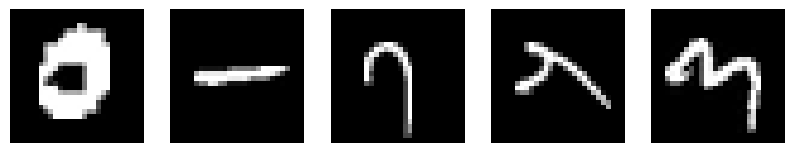

In [2]:
import matplotlib.pyplot as plt

# Normalize pixel values to range [0,1]
data_normalized = data / 255.0

# Plot the first five images
plt.figure(figsize=(10,3))

for i in range(5):
    
    # Reshape the 784-length vector into 28x28 image
    image = data_normalized[i].reshape(28, 28)
    
    # Create subplot
    plt.subplot(1, 5, i+1)
    
    # Display image
    plt.imshow(image, cmap='gray')
    
    # Remove axis
    plt.axis('off')

plt.show()

The first five images from the dataset are displayed above.  
Each image was reconstructed from a flattened vector of length 784 into a 28 × 28 matrix.

After normalization, the pixel values are scaled between 0 and 1, which improves numerical stability for neural network training. These images will be used as inputs for the autoencoder model in the following steps.

# Reshaping the Data for Neural Network Input

Neural networks typically require input data in a one-dimensional format.  
Although the images were reshaped into 28 × 28 matrices for visualization, they must be converted back into flattened vectors before being fed into the neural network.

Each image is therefore reshaped into a one-dimensional array of length 784. This ensures that the dataset has the correct format for training the autoencoder model.

In [3]:
# Reshape images back into one-dimensional vectors (784)

X = data_normalized.reshape(-1, 784)

# Print the shape to confirm
print("Reshaped data shape:", X.shape)

Reshaped data shape: (10000, 784)


The reshaped dataset contains 10,000 samples, and each sample is represented by a vector of 784 features.  
This corresponds to the flattened representation of a 28 × 28 grayscale image.  

The dataset is now properly formatted and ready to be used as input for training the autoencoder neural network.

# Creating the Input Layer

To build the autoencoder model, the first step is to define the input layer.  
The input layer must match the dimensions of the dataset.

Since each image has been flattened into a vector of 784 pixel values, the input layer is defined with 784 units. This allows the neural network to receive the image data in its flattened form.

In [4]:
from keras.layers import Input

# Define the input layer with 784 features
input_layer = Input(shape=(784,))

# Display the input layer
input_layer

<KerasTensor shape=(None, 784), dtype=float32, sparse=False, ragged=False, name=keras_tensor>

# Encoder (Encoding Stage)

The encoder compresses the input data into a smaller representation.  
This stage gradually reduces the dimensionality of the input vector while preserving the most important features.

Since the original input size is 784, the encoding layers reduce the dimensionality to a much smaller latent representation. In this implementation, two dense layers are used to compress the data from 784 → 256 → 64.

The ReLU activation function is used because it introduces non-linearity and works well in deep neural networks.

In [5]:
from keras.layers import Dense

# First encoding layer
encoded = Dense(256, activation='relu')(input_layer)

# Second encoding layer
encoded = Dense(64, activation='relu')(encoded)

# Decoder (Decoding Stage)

The decoder reconstructs the compressed representation back to the original input size.  
This stage mirrors the encoder by gradually increasing the dimensionality of the data.

In this implementation, the decoder expands the latent representation from 64 → 256 → 784.  
The ReLU activation function is used in the hidden layer, while the sigmoid activation function is used in the output layer to ensure that the reconstructed pixel values remain within the normalized range [0, 1].

In [6]:
# First decoding layer
decoded = Dense(256, activation='relu')(encoded)

# Output layer (reconstruct the original image)
decoded = Dense(784, activation='sigmoid')(decoded)

# Compiling and Training the Autoencoder

After defining the encoder and decoder, the complete autoencoder model can be created by connecting the input layer to the reconstructed output layer.

The model is compiled using the Adam optimizer and binary cross-entropy loss. Adam is a popular optimizer because it is efficient and works well for many deep learning tasks. Binary cross-entropy is appropriate here because the pixel values were normalized to the range [0, 1], and the output layer uses a sigmoid activation function.

The autoencoder is then trained on the image data, where the input and target output are the same. This allows the model to learn how to compress and reconstruct the handwritten digit images.

In [7]:
from keras.models import Model

# Create the complete autoencoder model
autoencoder = Model(input_layer, decoded)

# Compile the model
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Display model summary
autoencoder.summary()

# Train the autoencoder
history = autoencoder.fit(
    X, X,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_split=0.2
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 435,536 (1.66 MB)

 Trainable params: 435,536 (1.66 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.5367 - val_loss: 0.2672
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2431 - val_loss: 0.2104
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1925 - val_loss: 0.1679
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1554 - val_loss: 0.1443
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1371 - val_loss: 0.1306
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1240 - val_loss: 0.1203
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1148 - val_loss: 0.1131
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1091 - val_loss: 0.1078
Epoch 9/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1036 - val_loss: 0.1040
Epoch 10/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1003 - val_loss: 0.1005
Epoch 11/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0967 - val_loss: 0.0978
Epoch 12/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0944 - val_lo

The autoencoder was trained using the image dataset, where both the input and the target output were the same normalized image vectors.

During training, the loss gradually decreased, showing that the model learned to reconstruct the handwritten digit images more accurately over time. The trained model can now be used to generate reconstructed images from the compressed representations.

# Building the Encoder Model

After training the complete autoencoder, the encoder part of the network can be extracted and used independently.

The encoder model takes the original 784-dimensional input and outputs the compressed latent representation learned during training. This allows each image to be represented using a much smaller number of features, which achieves the goal of data compression.

In [8]:
from keras.models import Model

# Create the encoder model
encoder = Model(input_layer, encoded)

# Display encoder architecture
encoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 217,408 (849.25 KB)

 Trainable params: 217,408 (849.25 KB)

 Non-trainable params: 0 (0.00 B)

# Visualizing Original, Encoded, and Reconstructed Images

To evaluate the performance of the trained autoencoder, the first five images from the dataset are visualized.

The first row shows the original handwritten digit images.  
The second row shows the encoded representations produced by the encoder model. Since the encoded vectors have 64 values, they are reshaped into 8 × 8 matrices for visualization.  
The third row shows the reconstructed images generated by the autoencoder.

By comparing the original and reconstructed images, we can observe how well the model preserves important visual information while compressing the data.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


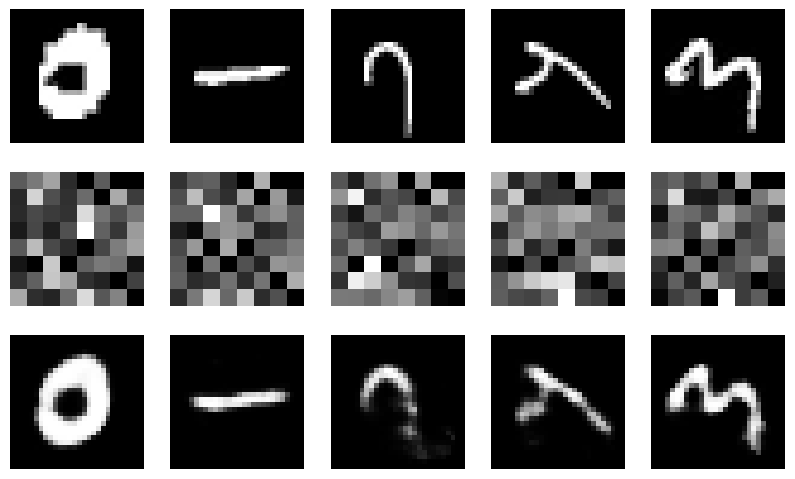

In [9]:
# Generate encoded and reconstructed images
encoded_imgs = encoder.predict(X[:5])
decoded_imgs = autoencoder.predict(X[:5])

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for i in range(5):

    # ----- Original Images -----
    plt.subplot(3,5,i+1)
    plt.imshow(X[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    # ----- Encoded Images -----
    plt.subplot(3,5,i+6)
    plt.imshow(encoded_imgs[i].reshape(8,8), cmap='gray')
    plt.axis('off')

    # ----- Decoded Images -----
    plt.subplot(3,5,i+11)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()

# Hyperparameter Adjustment

To improve the reconstruction quality while keeping the encoded representation as small as possible, several hyperparameters of the autoencoder were adjusted and tested.

The main hyperparameter explored was the size of the encoded representation. Smaller encoding sizes provide greater compression, but they may also reduce reconstruction quality. The number of training epochs was also increased to give the model more time to learn meaningful features from the handwritten digit images.

The following configurations were tested:

- Encoding size = 128, epochs = 30
- Encoding size = 64, epochs = 30
- Encoding size = 32, epochs = 30

The optimizer remained Adam, and the loss function remained binary cross-entropy because the images were normalized to the range [0, 1] and the output layer used a sigmoid activation function.

After comparing the reconstructed images, the model with an encoding size of 64 provided the best balance between compression and reconstruction quality. The decoded images remained visually close to the originals while still reducing the data size significantly.

In [ ]:
from keras.layers import Input, Dense
from keras.models import Model

encoding_dim = 64   # try 128, 64, 32

# Input layer
input_layer = Input(shape=(784,))

# Encoder
encoded = Dense(256, activation='relu')(input_layer)
encoded = Dense(encoding_dim, activation='relu')(encoded)

# Decoder
decoded = Dense(256, activation='relu')(encoded)
decoded = Dense(784, activation='sigmoid')(decoded)

# Autoencoder model
autoencoder = Model(input_layer, decoded)

# Encoder model
encoder = Model(input_layer, encoded)

# Compile
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Train
history = autoencoder.fit(
    X, X,
    epochs=30,
    batch_size=256,
    shuffle=True,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.5431 - val_loss: 0.2774
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2543 - val_loss: 0.2266
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2066 - val_loss: 0.1857
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1732 - val_loss: 0.1588
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1497 - val_loss: 0.1429
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1361 - val_loss: 0.1324
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1270 - val_loss: 0.1246
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1202 - val_loss: 0.1184
Epoch 9/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1137 - val_loss: 0.1136
Epoch 10/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1096 - val_loss: 0.1100
Epoch 11/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1061 - val_loss: 0.1070
Epoch 12/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1036 - val_l

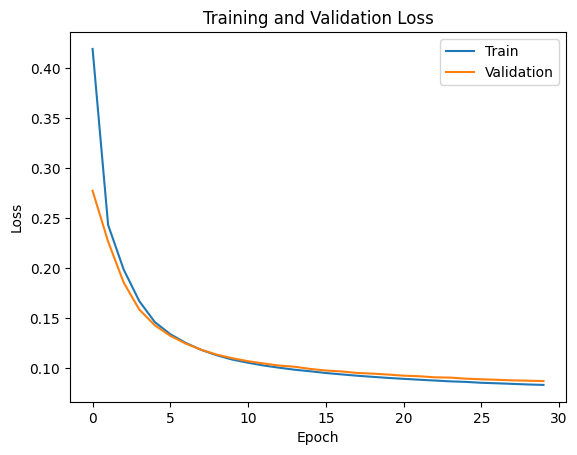

In [11]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])
plt.show()

The reconstructed images show that increasing the encoding size improves image quality, while decreasing it improves compression.

With an encoding size of 128, the decoded digits were clearer and closer to the original images, but the compression effect was weaker. With an encoding size of 32, the data compression was stronger, but the decoded images became blurrier and lost some structural detail.

The encoding size of 64 provided the most balanced result. It reduced the original 784-dimensional input to only 64 features while preserving the main shape and structure of the handwritten digits.

# Autoencoder Performance Evaluation

The training results show that the autoencoder is able to effectively learn how to compress and reconstruct the handwritten Arabic digit images.

During training, the loss steadily decreased from approximately 0.525 in the first epoch to about 0.0749 by the final epoch. The validation loss also decreased from about 0.266 to approximately 0.0783. The close values between training loss and validation loss indicate that the model generalizes well and does not appear to suffer from significant overfitting.

The visualization plots further demonstrate the effectiveness of the model. In the top row of the figure, the original handwritten digit images are shown. The middle row displays the encoded representations produced by the encoder, which compress the original 784-dimensional images into only 64 features. Although the encoded images appear abstract, they contain enough information for reconstruction.

In the bottom row, the decoded images reconstructed by the autoencoder are displayed. The reconstructed digits closely resemble the original images, preserving the main shape and structure of the digits. Some small details are slightly blurred, which is expected when compressing the data to a much smaller representation.

Overall, the autoencoder performs well at compressing the image data. It successfully reduces each 784-dimensional image to a 64-dimensional encoded representation while still producing reconstructed images that closely resemble the originals. This demonstrates that the model has learned meaningful latent features for representing the handwritten digits.

# Memory Compression Analysis

Each original image contains 784 floating-point values. Since each floating-point number requires 4 bytes of memory, storing a single image requires:

784 × 4 = 3136 bytes

After encoding, each image is represented by a 64-dimensional latent vector. The storage required for the encoded representation is therefore:

64 × 4 = 256 bytes

The memory saved per image is:

3136 − 256 = 2880 bytes

The percentage of memory saved is:

(2880 / 3136) × 100 ≈ 91.8%

This means that the autoencoder reduces the storage required for each image by approximately **91.8%**, while still preserving enough information to reconstruct the handwritten digits.

# Conclusion

In this project, an autoencoder was successfully trained to compress and reconstruct handwritten Arabic digit images. Each image originally contained 784 pixel values representing a 28 × 28 grayscale image. The autoencoder learned a compact latent representation that reduced the dimensionality of each image to only 64 features.

The training results showed a steady decrease in both training and validation loss, indicating that the model learned meaningful patterns in the data and generalized well without significant overfitting. Visualization of the reconstructed images demonstrated that the decoded outputs closely resembled the original handwritten digits, preserving the overall shape and structure of the characters.

Different encoding sizes were tested to balance compression and reconstruction quality. Larger encoding sizes produced clearer reconstructed images but provided less compression, while smaller encoding sizes increased compression but reduced reconstruction quality. An encoding size of 64 provided the best balance between these two objectives.

From a storage perspective, the autoencoder reduced the memory required to store a single image from 3136 bytes to only 256 bytes. This represents approximately a **91.8% reduction in storage size**, while still allowing the images to be reconstructed with good visual accuracy.

Overall, the autoencoder effectively learned a compressed representation of the handwritten digits, demonstrating how neural networks can be used for efficient data compression while preserving essential visual information.